<a href="https://colab.research.google.com/github/BuketPolatoglu/customer-potential-prediction/blob/main/customer_potential_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd # Veri manipülasyonu
import numpy as np  # Matematiksel işlemler
import matplotlib.pyplot as plt # Görselleştirme
import seaborn as sns # Gelişmiş görselleştirme
from sklearn.model_selection import train_test_split # Veriyi bölme
from sklearn.ensemble import RandomForestRegressor # Algoritma
from sklearn.metrics import mean_squared_error, r2_score # Başarı ölçümü

In [ ]:
import os


dosyalar = os.listdir('/content/drive/MyDrive/')
print(dosyalar)

['Colab Notebooks', 'Dear Erasmus Office.pdf', 'Buket Polatoğlu.pdf', 'n8n-rag-example', 'website_rag_chatbot.json adlı dosyanın kopyası', 'n8n-example', "Chrome'dan kaydedilenler", 'turkiye_2026_bankacilik_verisi.csv']


In [ ]:
import pandas as pd

dosya_yolu ='/content/drive/MyDrive/turkiye_2026_bankacilik_verisi.csv'


df = pd.read_csv(dosya_yolu)

df.head()

,Musteri_ID,Musteri_Adi,Yas,Cinsiyet,Sehir,Plaka_Kodu,Sehir_Tipi,Ekonomik_Bolge_Seviyesi,Meslek,Gelir_Tipi,...,Kart_Tipi,Kredi_Karti_Limiti_TL,Toplam_Borc_TL,Limit_Kullanim_Orani,Son_Ay_Odenen_TL,Aylik_Odeme_Yuzdesi,Asgari_Odeme_Zorunlulugu,Gecikme_Gun_Sayisi,Musteri_Skoru,Hesap_Aktif
0,TR2026000001,Engin,23,E,Kastamonu,37,Tarım & Orman,0.48,Freelancer_Digital,Serbest,...,Standard_Debit,71000,0,0.0,0,71.3,30,0,74,True
1,TR2026000002,Tuğçe,41,K,Çanakkale,17,Turizm & Tarım,0.60,Ciftci,Ticari,...,Ciftci_Karti,71800,69200,96.4,12940,18.7,30,10,30,False
2,TR2026000003,Zehra,90,K,Konya,42,Tarım & Sanayi,0.65,Emekli,Maasli,...,Emekli_Karti,20600,12920,62.7,3950,30.6,20,0,42,True
3,TR2026000004,Cumali,37,E,İstanbul,34,Finans & Ticaret,0.95,Emekli,Maasli,...,Standard_Debit,41400,0,0.0,0,32.8,0,0,46,False
4,TR2026000005,Sude,42,K,Bursa,16,Büyükşehir & Sanayi,0.80,Ev_Hanimi,Pasif_Gelir,...,Sanal_Kart,28100,9970,35.5,9610,96.4,0,0,76,False


In [ ]:
# Verinin genel yapısı ve veri tipleri
print("--- Veri Bilgisi ---")
print(df.info())

# Eksik veri kontrolü (GitHub'da 'temiz veriyle çalıştım' demek için önemli)
print("\n--- Eksik Veri Sayısı ---")
print(df.isnull().sum())

# Sayısal sütunların istatistiksel özeti
print("\n--- İstatistiksel Özet ---")
df.describe()

--- Veri Bilgisi ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Musteri_ID                100000 non-null  object 
 1   Musteri_Adi               100000 non-null  object 
 2   Yas                       100000 non-null  int64  
 3   Cinsiyet                  100000 non-null  object 
 4   Sehir                     100000 non-null  object 
 5   Plaka_Kodu                100000 non-null  int64  
 6   Sehir_Tipi                100000 non-null  object 
 7   Ekonomik_Bolge_Seviyesi   100000 non-null  float64
 8   Meslek                    100000 non-null  object 
 9   Gelir_Tipi                100000 non-null  object 
 10  Egitim_Durumu             100000 non-null  object 
 11  Kart_Tipi                 100000 non-null  object 
 12  Kredi_Karti_Limiti_TL     100000 non-null  int64  
 13  Toplam_Borc_TL          

,Yas,Plaka_Kodu,Ekonomik_Bolge_Seviyesi,Kredi_Karti_Limiti_TL,Toplam_Borc_TL,Limit_Kullanim_Orani,Son_Ay_Odenen_TL,Aylik_Odeme_Yuzdesi,Asgari_Odeme_Zorunlulugu,Gecikme_Gun_Sayisi,Musteri_Skoru
count,100000.00000,100000.000000,100000.000000,1.000000e+05,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,43.31487,33.748290,0.688624,7.199156e+04,2.171324e+04,31.539556,13510.672100,53.077728,18.046250,1.124750,55.784000
std,17.22357,19.584923,0.190863,1.082400e+05,3.917541e+04,32.490228,28681.564256,28.808805,16.584688,5.793792,17.402875
min,18.00000,1.000000,0.280000,2.000000e+03,0.000000e+00,0.000000,0.000000,3.000000,0.000000,0.000000,10.000000
25%,29.00000,19.000000,0.550000,1.830000e+04,0.000000e+00,0.000000,0.000000,29.800000,0.000000,0.000000,43.000000
50%,41.00000,34.000000,0.680000,3.010000e+04,4.950000e+03,24.400000,2450.000000,41.600000,20.000000,0.000000,50.000000
75%,56.00000,45.000000,0.850000,7.720000e+04,2.470250e+04,58.025000,10090.000000,82.000000,30.000000,0.000000,72.000000
max,90.00000,81.000000,0.950000,1.788400e+06,1.212750e+06,98.000000,441640.000000,100.000000,40.000000,60.000000,94.000000


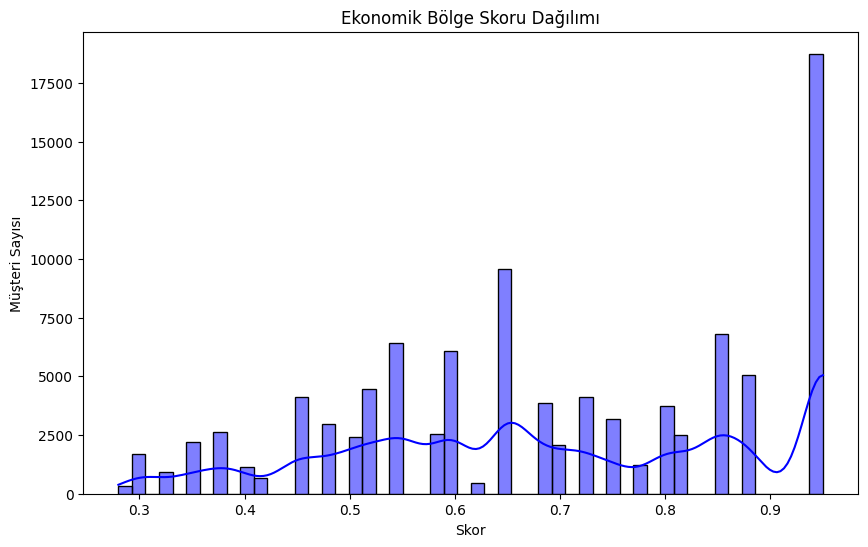

                Yas     Plaka_Kodu  Ekonomik_Bolge_Seviyesi  \
count  100000.00000  100000.000000            100000.000000   
mean       43.31487      33.748290                 0.688624   
std        17.22357      19.584923                 0.190863   
min        18.00000       1.000000                 0.280000   
25%        29.00000      19.000000                 0.550000   
50%        41.00000      34.000000                 0.680000   
75%        56.00000      45.000000                 0.850000   
max        90.00000      81.000000                 0.950000   

       Kredi_Karti_Limiti_TL  Toplam_Borc_TL  Limit_Kullanim_Orani  \
count           1.000000e+05    1.000000e+05         100000.000000   
mean            7.199156e+04    2.171324e+04             31.539556   
std             1.082400e+05    3.917541e+04             32.490228   
min             2.000000e+03    0.000000e+00              0.000000   
25%             1.830000e+04    0.000000e+00              0.000000   
50%         

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Hedef Değişkenin (Potansiyel) Dağılımı
plt.figure(figsize=(10, 6))
sns.histplot(df['Ekonomik_Bolge_Seviyesi'], kde=True, color='blue')
plt.title('Ekonomik Bölge Skoru Dağılımı')
plt.xlabel('Skor')
plt.ylabel('Müşteri Sayısı')
plt.show()

# 2. Sayısal verilerin özet istatistikleri
print(df.describe())

In [ ]:
# 1. Yaş Gruplarını Oluşturma (Binning)
# Sayısal yaşı 'Genc', 'Profesyonel', 'Emekli' kategorilerine ayırıyoruz.
bins = [17, 25, 55, 100]
labels = ['Genc', 'Profesyonel', 'Emekli']
df['Yas_Grubu'] = pd.cut(df['Yas'], bins=bins, labels=labels)

# 2. Tahmin için gereksiz veya çok karmaşık sütunları eleme
# Musteri_ID ve Isim gibi veriler matematiksel bir anlam taşımaz.
# Sehir sütunu ise çok fazla farklı değer içerdiği için modelin kafasını karıştırabilir.
drop_cols = ['Musteri_ID', 'Musteri_Adi', 'Sehir', 'Plaka_Kodu']
df_filtered = df.drop(columns=drop_cols)

# 3. One-Hot Encoding (Kategorik verileri sayıya çevirme)
# 'Meslek', 'Gelir_Tipi' gibi metin sütunlarını 0 ve 1'lerden oluşan yeni sütunlara bölüyoruz.
kategorik_liste = ['Cinsiyet', 'Sehir_Tipi', 'Meslek', 'Gelir_Tipi', 'Egitim_Durumu', 'Kart_Tipi', 'Yas_Grubu']
df_final = pd.get_dummies(df_filtered, columns=kategorik_liste)

# Yeni oluşan tablonun boyutunu ve ilk 5 satırını görelim
print("Orijinal Sütun Sayısı: 21")
print("Yeni (Encoded) Sütun Sayısı:", df_final.shape[1])
df_final.head()

Orijinal Sütun Sayısı: 21
Yeni (Encoded) Sütun Sayısı: 85


,Yas,Ekonomik_Bolge_Seviyesi,Kredi_Karti_Limiti_TL,Toplam_Borc_TL,Limit_Kullanim_Orani,Son_Ay_Odenen_TL,Aylik_Odeme_Yuzdesi,Asgari_Odeme_Zorunlulugu,Gecikme_Gun_Sayisi,Musteri_Skoru,...,Kart_Tipi_Mile_Travel,Kart_Tipi_Prepaid_Social_Aid,Kart_Tipi_Sanal_Kart,Kart_Tipi_Standard_Credit,Kart_Tipi_Standard_Debit,Kart_Tipi_Ticari_Business,Kart_Tipi_VIP_Premium,Yas_Grubu_Genc,Yas_Grubu_Profesyonel,Yas_Grubu_Emekli
0,23,0.48,71000,0,0.0,0,71.3,30,0,74,...,False,False,False,False,True,False,False,True,False,False
1,41,0.60,71800,69200,96.4,12940,18.7,30,10,30,...,False,False,False,False,False,False,False,False,True,False
2,90,0.65,20600,12920,62.7,3950,30.6,20,0,42,...,False,False,False,False,False,False,False,False,False,True
3,37,0.95,41400,0,0.0,0,32.8,0,0,46,...,False,False,False,False,True,False,False,False,True,False
4,42,0.80,28100,9970,35.5,9610,96.4,0,0,76,...,False,False,True,False,False,False,False,False,True,False


In [ ]:
# Meslek ile başlayan tüm yeni sütunları listeler
print([col for col in df_final.columns if 'Meslek' in col])

['Meslek_Beyaz_Yaka_Uzman', 'Meslek_Beyaz_Yaka_Yonetici', 'Meslek_Ciftci', 'Meslek_Emekli', 'Meslek_Esnaf_Kobi', 'Meslek_Ev_Hanimi', 'Meslek_Freelancer_Digital', 'Meslek_Issiz_Sosyal_Yardim', 'Meslek_Mavi_Yaka_Isci', 'Meslek_Ogrenci']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Hedef değişken (tahmin edilecek değer) ve özellikleri ayıralım
# 'Ekonomik_Bolge_Seviyesi' bizim hedefimiz (y), geri kalan her şey girdi (X)
y = df_final['Ekonomik_Bolge_Seviyesi']
X = df_final.drop(columns=['Ekonomik_Bolge_Seviyesi'])

# 2. Veriyi Eğitim (%80) ve Test (%20) seti olarak bölelim
# Test setini, modelin başarısını daha önce hiç görmediği verilerle ölçmek için ayırıyoruz.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Modeli tanımlayalım (Random Forest - Rastgele Orman Algoritması)
# Karmaşık ilişkileri yakalamakta çok başarılı bir algoritmadır.
model = RandomForestRegressor(n_estimators=100, random_state=42)

# 4. Modeli eğitelim (Bu işlem veri boyutuna göre 10-20 saniye sürebilir)
print("Model eğitiliyor, lütfen bekleyin...")
model.fit(X_train, y_train)

# 5. Tahmin yapalım ve başarıyı ölçelim
y_pred = model.predict(X_test)

# Başarı Metrikleri
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\n--- MODEL BAŞARI RAPORU ---")
print(f"R-Kare (R2) Skoru: %{r2*100:.2f}")
print(f"Hata Oranı (MSE): {mse:.4f}")

Model eğitiliyor, lütfen bekleyin...

--- MODEL BAŞARI RAPORU ---
R-Kare (R2) Skoru: %97.26
Hata Oranı (MSE): 0.0010


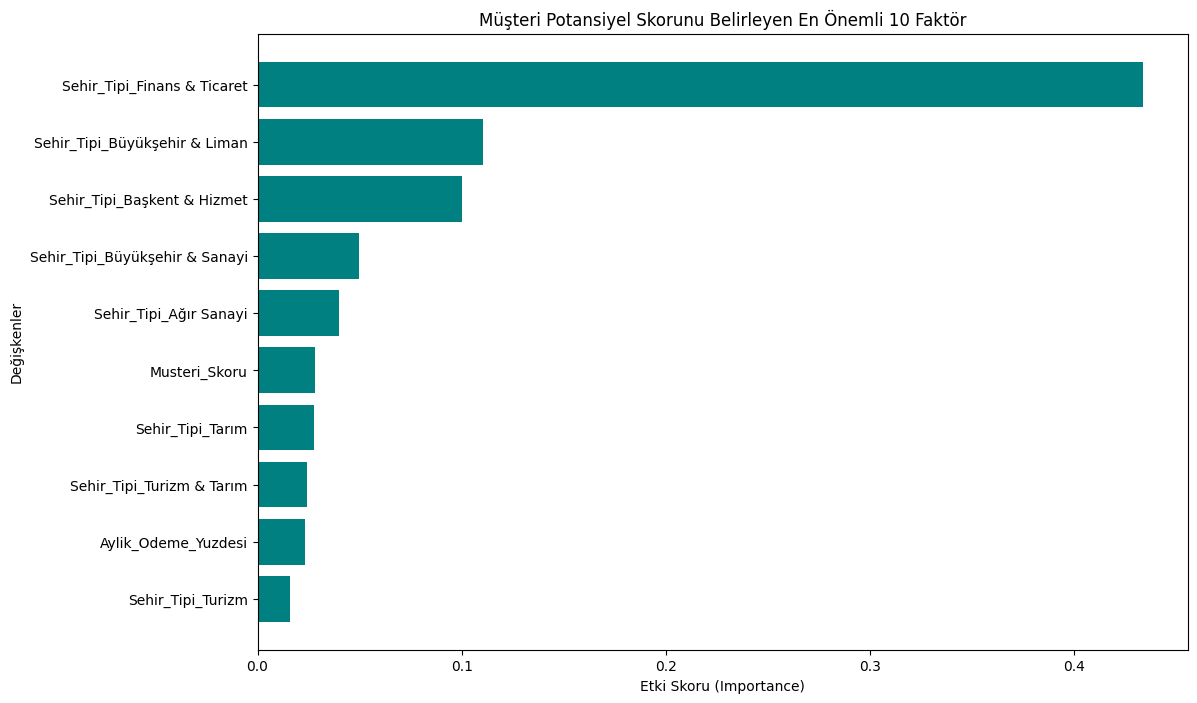

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Modelden özellik önemlerini alalım
importances = model.feature_importances_
feature_names = X.columns

# Bunları bir DataFrame'e dönüştürüp sıralayalım
feature_importance_df = pd.DataFrame({'Özellik': feature_names, 'Önem': importances})
feature_importance_df = feature_importance_df.sort_values(by='Önem', ascending=False).head(10) # En önemli 10 tanesi

# Görselleştirme
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Özellik'], feature_importance_df['Önem'], color='teal')
plt.xlabel('Etki Skoru (Importance)')
plt.ylabel('Değişkenler')
plt.title('Müşteri Potansiyel Skorunu Belirleyen En Önemli 10 Faktör')
plt.gca().invert_yaxis() # En önemliyi en üste koyar
plt.show()

In [ ]:
import joblib

# Modeli bilgisayarına/drive'a kaydet
joblib.dump(model, 'musteri_potansiyel_modeli.pkl')

['musteri_potansiyel_modeli.pkl']

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
# Veriyi hazırlayalım (Önceki adımda oluşturduğumuz feature_importance_df'i kullanıyoruz)
fig = px.bar(feature_importance_df,
             x='Önem',
             y='Özellik',
             orientation='h',
             title='Müşteri Potansiyel Skorunu Belirleyen Faktörler (İnteraktif)',
             labels={'Önem':'Etki Puanı', 'Özellik':'Değişkenler'},
             color='Önem',
             color_continuous_scale='Viridis')

fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

In [ ]:
# 1000 örneklem seçelim ki grafik kasmadan akıcı görünsün
df_sample = df.sample(1000)

fig = px.scatter(df_sample,
                 x='Yas',
                 y='Ekonomik_Bolge_Seviyesi',
                 color='Sehir_Tipi',
                 hover_data=['Meslek', 'Gelir_Tipi'],
                 title='Yaş ve Şehir Tipine Göre Potansiyel Dağılımı',
                 opacity=0.7)

fig.show()